In [1]:
#################   General Linear Model tests using baseline time point only   ###################

# load the correponding dataset by un-commenting the corresponding line


In [97]:
import numpy as np
import pandas as pd

from scipy.stats import shapiro   # for normality test

from scipy.stats import f_oneway  # for Anova test (normal distribution)
from scipy.stats import kruskal   # for Kruskal-Wallis test (non-normal distribution)

import statsmodels.api as sm      # for Ancova, , non-formular form
import statsmodels.formula.api as smf # for ANCOVA test, formular form

from scipy.stats import rankdata  # for Rank-Based ANCOVA, for Non-Gaussian distributions

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
curRoot = 'C'  # 'C' or 'D'
# Load shape measures, SELECTED
curRegion = 'CSSyl' # !!! modify !!! CSSyl, CSpreCS
curSCA = 1         # !!! modify !!!
typeDist = 'max'

##############################################   Original   #############################################
# for CSpreCS analysis
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca1_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca2_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca3_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca7_time1_{typeDist}.csv'

#file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'

# Time 1 and 2 separated, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_{typeDist}.csv'

# Time 1 and 2 combined, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_{typeDist}.csv'

#Original, time1 only
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_{typeDist}.csv'

#Original REDO for verification
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\ORI\ORI_time1_ctl_sca1\{curRegion}\combined_time1_{typeDist}_ctl_sca1.csv'

# SCAs 2, 3, 7
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_{typeDist}.csv'

###########################################    RELABEL     #############################################
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'

###########################################   RELABEL, REDO    #############################################
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_{typeDist}_ctl_sca{curSCA}.csv'
curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time2_ctl_sca{curSCA}\{curRegion}\combined_time2_{typeDist}_ctl_sca{curSCA}.csv'

print(curPath)
combined = pd.read_csv(curPath)
print(len(combined))

### !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!  ###
####################################  only for time1 and 2 together  ####################################
#combined_time1 = combined[combined['Time_point']==1]
#combined_time2 = combined[combined['Time_point']!=1] # BIOSCA==2, CERMOI==3
#combined = combined_time2         ###########################    CHANGE    #############################
### !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!  ###

combined.index = combined['subjName']

# for specific analysis, remove NAs
combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_only_SCA = combined[combined['SCA'] == curSCA]

combined_CAG = combined.dropna(subset=['CAG'])
combined_CAG_only_SCA = combined_CAG[combined_CAG['SCA'] == curSCA]

combined_CCFS = combined.dropna(subset=['CCFS'])
combined_CCFS_only_SCA = combined_CCFS[combined_CCFS['SCA'] == curSCA]

combined_INAS = combined.dropna(subset=['INAS'])
combined_INAS_only_SCA = combined_INAS[combined_INAS['SCA'] == curSCA]

C:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_ctl_sca1\CSSyl\combined_time1_max_ctl_sca1.csv
86


In [85]:
# Centering values
def centering_values(df):
    df.loc[:,'CAG_centered'] = df['CAG'] - df['CAG'].mean()
    df.loc[:,'SARA_centered'] = df['SARA'] - df['SARA'].mean()
    df.loc[:,'CCFS_centered'] = df['CCFS'] - df['CCFS'].mean()
    df.loc[:,'INAS_centered'] = df['INAS'] - df['INAS'].mean()    
    df.loc[:,'Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
    df.loc[:,'Age_centered'] = df['Age'] - df['Age'].mean()
    df.loc[:,'iso1_centered'] = df['iso1'] - df['iso1'].mean()   
    df.loc[:,'iso2_centered'] = df['iso2'] - df['iso2'].mean()       
    df.loc[:,'iso3_centered'] = df['iso3'] - df['iso3'].mean()   
    df.loc[:,'UMAP1_U1_centered'] = df['UMAP1_U1'] - df['UMAP1_U1'].mean()   
    df.loc[:,'UMAP1_U2_centered'] = df['UMAP1_U2'] - df['UMAP1_U2'].mean() 
    df.loc[:,'UMAP1_U3_centered'] = df['UMAP1_U3'] - df['UMAP1_U3'].mean() 
    df.loc[:,'UMAP2_U3_centered'] = df['UMAP2_U3'] - df['UMAP2_U3'].mean() 
    df.loc[:,'UMAP1_U4_centered'] = df['UMAP1_U4'] - df['UMAP1_U4'].mean() 
    df.loc[:,'UMAP2_U4_centered'] = df['UMAP2_U4'] - df['UMAP2_U4'].mean() 
    df.loc[:,'iso1_asy_centered'] = df['iso1_asy'] - df['iso1_asy'].mean()   
    df.loc[:,'iso2_asy_centered'] = df['iso2_asy'] - df['iso2_asy'].mean()       
    df.loc[:,'iso3_asy_centered'] = df['iso3_asy'] - df['iso3_asy'].mean()      
    return df

combined_centered =  centering_values(combined)


In [ ]:
#######################################  data inspections  #######################################

In [4]:
combined.columns

Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy', 'hull_

In [5]:
print(len(combined_CAG))
print(len(combined_only_SCA))
print(len(combined_CAG_only_SCA))
print(combined_CAG.columns)

44
32
32
Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy

In [6]:
########################################  Stats  #############################################

In [187]:
##############################  LMM, Result Verification   ############################## 
##  Since the hemisphere is a repeated measure even using one time point

# Create the new 'subject' column by removing prefixes
combined_centered['subject'] = (
    combined_centered['subjName']
    .str.replace(r'^L', '', regex=True)          # Remove 'L' if it starts the string
    .str.replace(r'^flip[-_]?R', '', regex=True) # Remove 'flip-R' or 'flip_R' if it starts the string
)


measure = 'iso1_centered'
x_var = 'C(SCA) + Age + C(side) + C(Sex)'  # Fixed effects
random_effect = 'subject'  # Subject identifier column

formula = rf'{measure} ~ {x_var}'  # Fixed effects formula

# Fit a linear mixed-effects model with subject as a random intercept
model = smf.mixedlm(formula, data=combined_centered, groups=combined_centered[random_effect])
result = model.fit()

# Output
print(rf'LMM results for ###################    {measure}    ###################:')
print(result.summary())
print("\n" + "="*80 + "\n")


LMM results for ###################    iso1_centered    ###################:
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: iso1_centered
No. Observations: 86      Method:             REML         
No. Groups:       43      Scale:              8.3990       
Min. group size:  2       Log-Likelihood:     -230.3477    
Max. group size:  2       Converged:          Yes          
Mean group size:  2.0                                      
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         4.065    1.870  2.174 0.030  0.400  7.729
C(SCA)[T.1]      -2.415    1.025 -2.355 0.019 -4.424 -0.405
C(side)[T.R]     -2.229    0.625 -3.566 0.000 -3.454 -1.004
C(Sex)[T.2]       1.482    0.990  1.497 0.135 -0.459  3.422
Age              -0.060    0.036 -1.666 0.096 -0.131  0.011
Group Var         6.154    1.123  

In [161]:
##############################  GLM, Result Verification   ############################## 
measure = 'iso1_centered'
#x_var = 'C(SCA) + Age + C(side)'
x_var = 'C(SCA) + Age + C(side) + C(Sex)'
#x_var = 'C(SCA) + Age + C(side) + C(CodeICM)'

formula = rf'{measure} ~ {x_var}'   # Define the model formula dynamically       
model = smf.ols(formula, data=combined_centered).fit()            # Fit the model  

print(rf'ANCOVA results for ###################    {measure}    ###################:')
print(model.summary())
print("\n" + "="*80 + "\n")  # Divider between each measure's output
anova_table = sm.stats.anova_lm(model, typ=2) 
print(anova_table)
        

ANCOVA results for ###################    iso1_centered    ###################:
                            OLS Regression Results                            
Dep. Variable:          iso1_centered   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     5.398
Date:                Thu, 24 Jul 2025   Prob (F-statistic):           0.000664
Time:                        17:39:31   Log-Likelihood:                -233.92
No. Observations:                  86   AIC:                             477.8
Df Residuals:                      81   BIC:                             490.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [165]:
#################  To understand the magnitute and direction of the difference  ################
## When used for post-hoc, check p-value here only if more than 2 groups

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=combined_centered['iso1'], groups=combined_centered['SCA'], alpha=0.05)
print(tukey.summary())


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1  -2.3233 0.0114 -4.1091 -0.5375   True
----------------------------------------------------


In [167]:
###################  Calculate effect size, partial eta squared  ####################
## 0.01 small, 0.06 medium, +0.14 large effect

# Fit your OLS model
model = smf.ols('iso1_centered ~ C(SCA) + Age + C(side) + C(Sex)', data=combined_centered).fit()

# Get the ANOVA table (Type II sum of squares)
from statsmodels.stats.anova import anova_lm
anova_table = anova_lm(model, typ=2)

# Function to compute partial eta squared
def compute_partial_eta_squared(anova_table):
    # η²_partial = SS_effect / (SS_effect + SS_error)
    ss_total_error = anova_table.loc['Residual', 'sum_sq']
    eta_squared = {}

    for effect in anova_table.index:
        if effect != 'Residual':
            ss_effect = anova_table.loc[effect, 'sum_sq']
            eta_squared[effect] = ss_effect / (ss_effect + ss_total_error)

    return eta_squared

eta_squared_values = compute_partial_eta_squared(anova_table)

# Display partial η² for each effect
for effect, eta in eta_squared_values.items():
    print(f"Partial η² for {effect}: {eta:.3f}")


Partial η² for C(SCA): 0.090
Partial η² for C(side): 0.084
Partial η² for C(Sex): 0.038
Partial η² for Age: 0.047


In [143]:
####################################  Model Diagnostics, tests  ######################################
model = smf.ols(formula='iso1_centered ~ C(SCA) + Age_centered + C(side) + C(Sex)', data=combined_centered).fit()
residuals = model.resid

##################  Normality test of the residual  ####################
# shapiro: if p > 0.05, not normal
from scipy.stats import shapiro
shapiro_stat, p_value = shapiro(model.resid)
print(f"Shapiro-Wilk p-value: {p_value:.4f}")

##################  Normality test of the residual  ####################
# Kolmogorov-Smirnov: if p > 0.05, not normal
# The K-S test is sensitive to outliers and assumes known parameters (mean and std). 
# When applied to estimated residuals, it can be conservative or misleading.
# It’s generally less powerful than the Shapiro-Wilk test for normality.
from scipy.stats import kstest, norm
ks_stat, ks_p = kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
print(f"Kolmogorov-Smirnov test p-value: {ks_p:.4f}")

#########################	 Heteroscedasticity Tests  ##########################
## If you’re concerned about non-constant variance: Breusch-Pagan test (for linear models):
## If > 0.05, no evidence of heteoscedasticity
from statsmodels.stats.diagnostic import het_breuschpagan
_, pval, _, _ = het_breuschpagan(residuals, model.model.exog)
print("Breusch-Pagan p-value:", pval)


Shapiro-Wilk p-value: 0.8438
Kolmogorov-Smirnov test p-value: 0.9872
Breusch-Pagan p-value: 0.16476623267092005


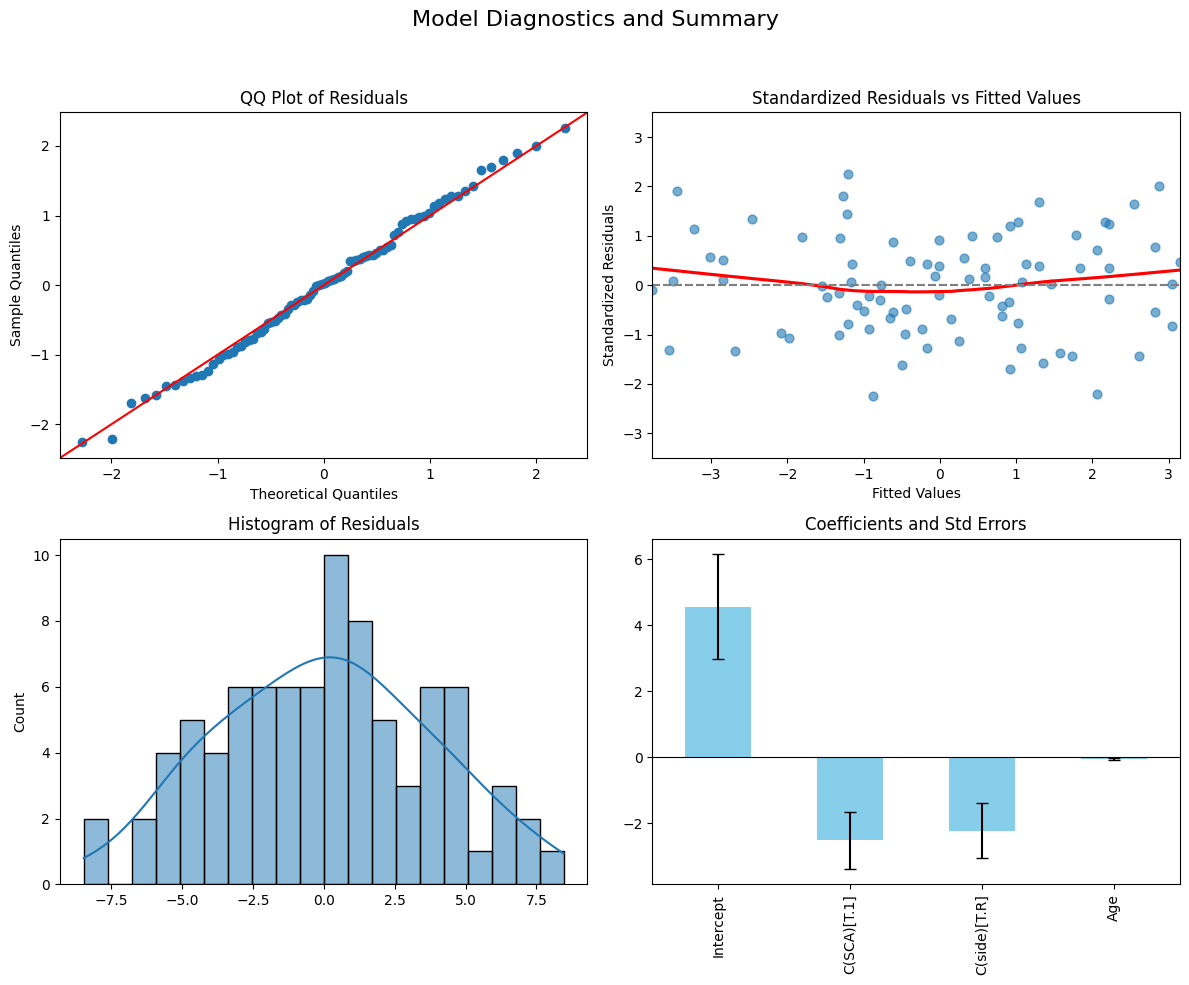

In [169]:
####################################  Model Diagnostics, plots  ######################################
# Fit your LMM
formula = "iso1 ~ C(SCA) + Age + C(side)"
model = smf.ols(formula, data=combined).fit()            # Fit the model  

# --- Print summary statistics ---
#print(model.summary())

# --- Set up multi-plot display ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Model Diagnostics and Summary', fontsize=16)

# --- QQ Plot ---
sm.qqplot(model.resid, line='45', ax=axs[0, 0],fit=True)
axs[0, 0].set_title('QQ Plot of Residuals')

# --- Residuals vs. Fitted ---
"""
############################  non-standardized residual  ###########################
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, ax=axs[0, 1],
              line_kws={'color': 'red'})
axs[0, 1].set_title('Residuals vs Fitted')
axs[0, 1].set_xlabel('Fitted values')
axs[0, 1].set_ylabel('Residuals')
"""
############################  standardized residual  ###########################
# normalized residuals, accounting for variance in the model.
# Values > ±2 or ±3 can indicate outliers.
# More interpretable than raw residuals when plotting diagnostics.
influence = model.get_influence()
standardized_resid = influence.resid_studentized_internal # Get studentized (standardized) residuals

sns.residplot(
    x=model.fittedvalues,
    y=standardized_resid,
    lowess=True,
    scatter_kws={'alpha': 0.6, 's': 40},
    line_kws={'color': 'red'},
    ax=axs[0, 1]
)

axs[0, 1].axhline(0, color='gray', linestyle='--')
axs[0, 1].set_title("Standardized Residuals vs Fitted Values")
axs[0, 1].set_xlabel("Fitted Values")
axs[0, 1].set_ylabel("Standardized Residuals")
axs[0, 1].set_ylim(-3.5, 3.5)  # Optional, but helps visually


# --- Histogram of Residuals ---
sns.histplot(model.resid, bins=20, kde=True, ax=axs[1, 0])
axs[1, 0].set_title('Histogram of Residuals')

# --- Coefficients bar plot ---
coefs = model.params
errors = model.bse
coefs.plot(kind='bar', yerr=errors, ax=axs[1, 1], color='skyblue', capsize=4)
axs[1, 1].set_title('Coefficients and Std Errors')
axs[1, 1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\GLM_ctl_Sca1\difference_diag.png')

plt.show()


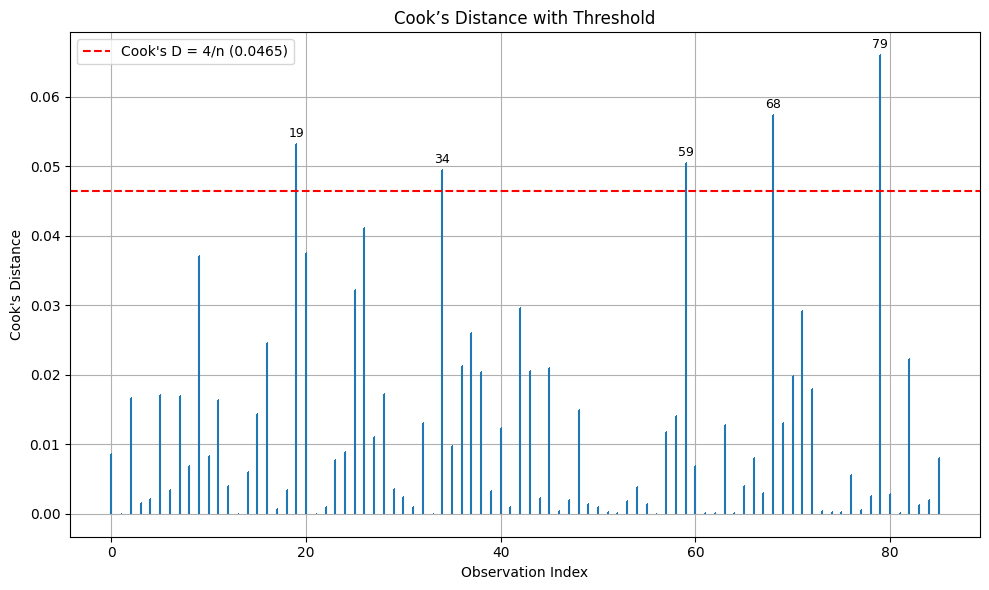


Top influential observations (by Cook's distance):
 obs_index          subjName  cooks_d
        79  flip-R00011EG_V1 0.066000
        68 flip-R001090RD_E1 0.057363
        19      L001077MR_E1 0.053265
        59 flip-R001073PM_E1 0.050444
        34       L00001PJ_V1 0.049430


In [171]:
########################  outlier diagnosis, Cook's distance Plot  #########################

# 1. Compute Cook's distance
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

# 2. Create DataFrame with observation index and subject info
df_cooks = pd.DataFrame({
    "obs_index": range(len(cooks_d)),
    "subjName": df["subjName"].values,  # assuming df has this column
    "cooks_d": cooks_d
})

# 3. Sort to get top N influential points
top_n = 5
top_cooks = df_cooks.sort_values("cooks_d", ascending=False).head(top_n)

# 4. Plot Cook’s Distance with threshold
plt.figure(figsize=(10, 6))
plt.stem(df_cooks["obs_index"], df_cooks["cooks_d"], markerfmt=",", basefmt=" ")

# Add Cook's D threshold line
n = len(df)  # number of observations
threshold = 4 / n
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Cook\'s D = 4/n ({threshold:.4f})')

# Annotate the top influential observations
for _, row in top_cooks.iterrows():
    plt.annotate(row["obs_index"],
                 (row["obs_index"], row["cooks_d"]),
                 textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)

plt.title("Cook’s Distance with Threshold")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\GLM_ctl_Sca1\difference_diag_Cook.png')
plt.show()

# 5. Print mapping of observation index to subject name
print("\nTop influential observations (by Cook's distance):")
print(top_cooks[["obs_index", "subjName", "cooks_d"]].to_string(index=False))


In [9]:
####    Data Inspection and Plotting    ####

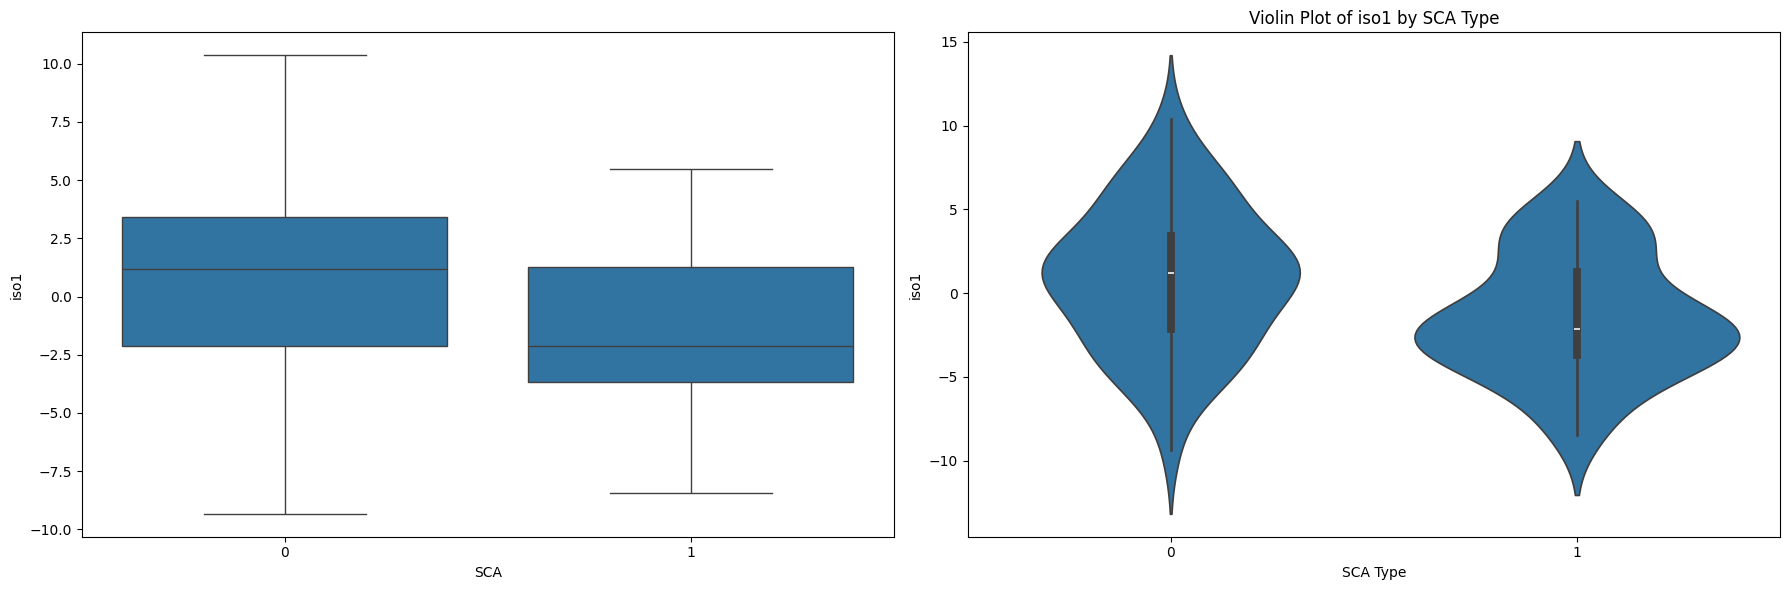

In [127]:
###########  simple boxplot  ###########

df = combined
curData = 'iso1'

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(x='SCA', y=curData, data=df, ax=axs[0])
plt.title('Box Plot of ' + curData + ' by SCA Type')
plt.xlabel('SCA Type')
plt.ylabel(curData)

sns.violinplot(x='SCA', y=curData, data=df, inner='box', ax=axs[1])
plt.title('Violin Plot of ' + curData + ' by SCA Type')
plt.xlabel('SCA Type')
plt.ylabel(curData)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_44628\3462804768.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SCA', y=new_name, data=df_cleaned, palette="Set3", ax=axs[1])
C:\Users\joyca\AppData\Local\Temp\ipykernel_44628\3462804768.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SCA', y=new_name, data=df_cleaned, palette="Set3")


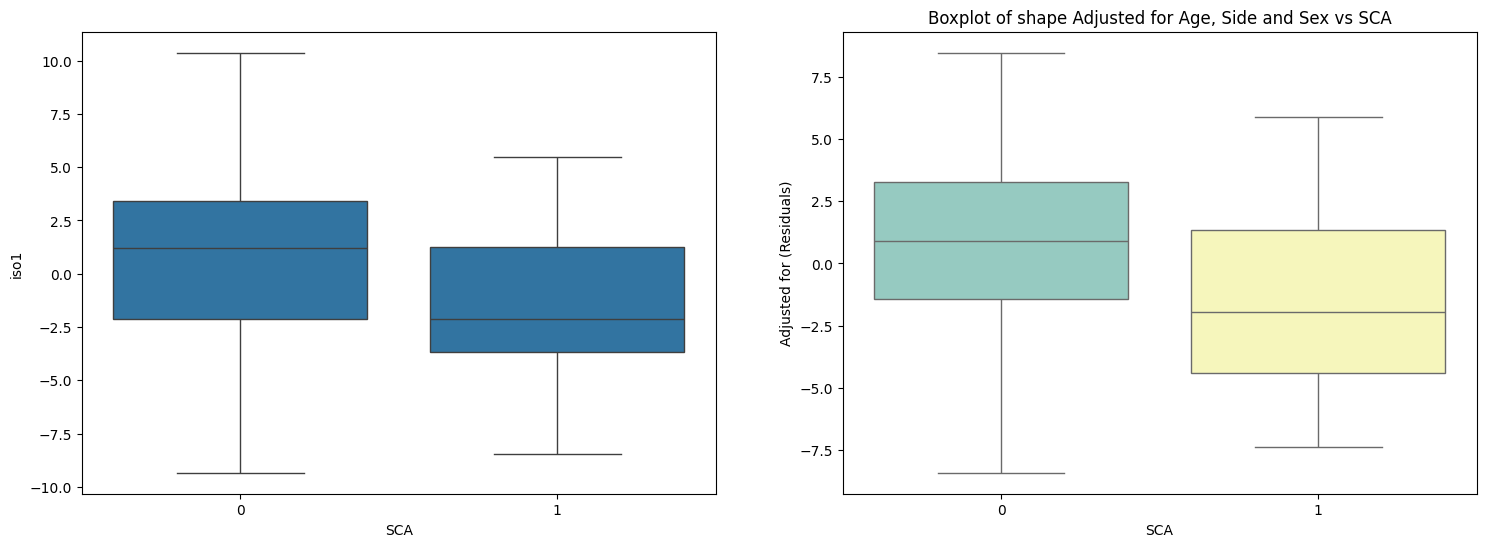

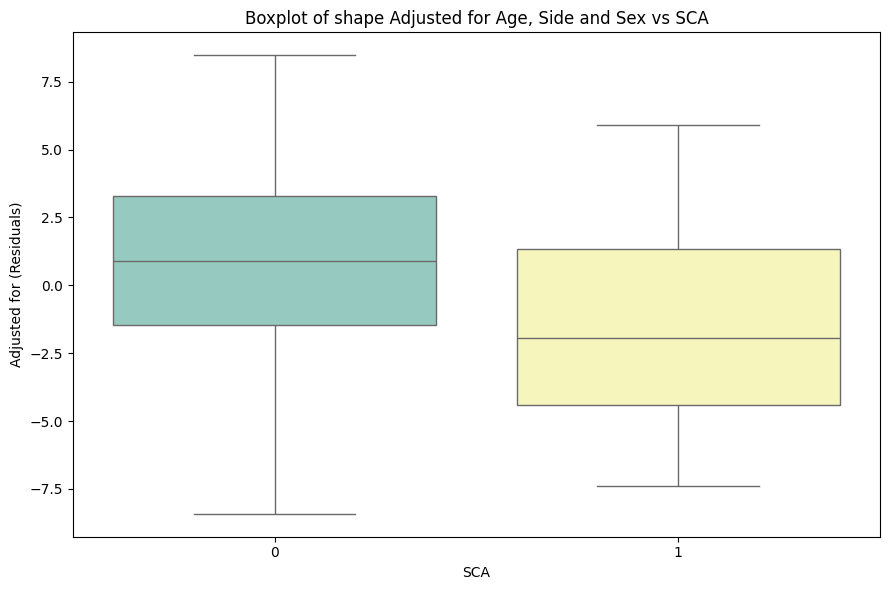

In [189]:
###########  boxplot with and without adjusting for cofactors  ###########
df = combined
curData = 'iso1'
new_name = curData + '_adjusted'

df['side_numeric'] = pd.Categorical(df['side'].map({'L': 0, 'R': 1}), categories=[0, 1])
df_cleaned = df
# Step 1: Drop rows with NaNs or infinite values in the relevant columns
##relevant_columns = [curData, 'Sex', 'Age', 'side_numeric', 'Disease_duration', 'Age_onset'] #THIS WILL REMOVE ALL CTLs
#relevant_columns = [curData, 'Sex', 'Age', 'side_numeric']
#df_cleaned = df.dropna(subset=relevant_columns)  # Drop rows with NaNs
#df_cleaned = df_cleaned.replace([np.inf, -np.inf], np.nan).dropna()  # Drop rows with infinities

# Step 2: Regress iso1 on Age and Sex to adjust for these cofactors
cofactors = ['Sex', 'Age', 'side_numeric']
X = sm.add_constant(df_cleaned[cofactors])  # Add constant for intercept
model = sm.OLS(df_cleaned[curData], X).fit()
df_cleaned[new_name] = model.resid  # Residuals represent iso1 adjusted for cofactors

# Step 3: COMPARE: Boxplot of original and adjusted iso1 vs SCA

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(x='SCA', y=curData, data=df, ax=axs[0])
plt.title('Box Plot of ' + curData + ' by SCA Type')
plt.xlabel('SCA Type')
plt.ylabel(curData)

sns.boxplot(x='SCA', y=new_name, data=df_cleaned, palette="Set3", ax=axs[1])
plt.title("Boxplot of shape Adjusted for Age, Side and Sex vs SCA")
plt.xlabel("SCA")
plt.ylabel("Adjusted for (Residuals)")



# OR: plot only the adjusted plot
plt.figure(figsize=(9, 6))  # Adjust figure size as needed

sns.boxplot(x='SCA', y=new_name, data=df_cleaned, palette="Set3")

plt.title("Boxplot of shape Adjusted for Age, Side and Sex vs SCA")
plt.xlabel("SCA")
plt.ylabel("Adjusted for (Residuals)")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\GLM_ctl_Sca1\difference_box_residual.png')
plt.show()

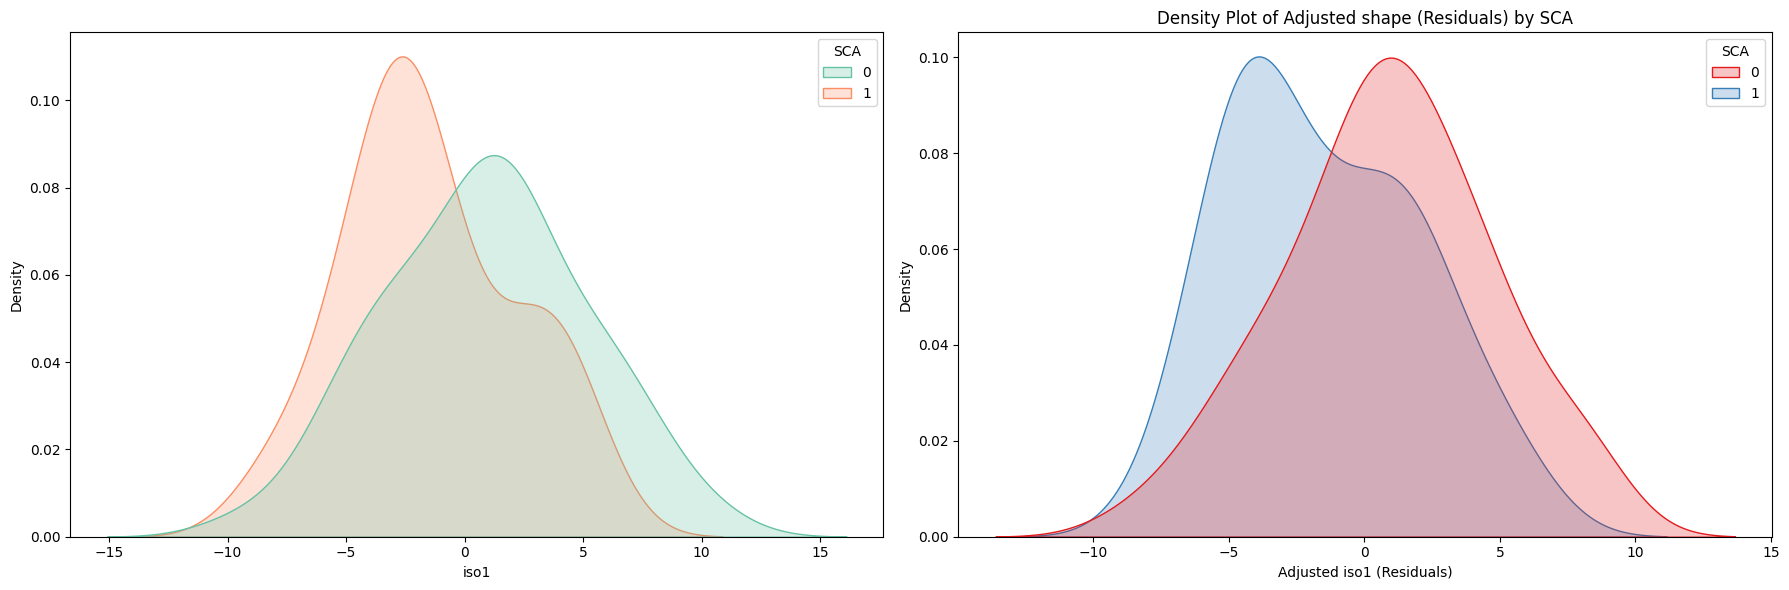

In [131]:
###########  density plot with and without adjusting for cofactors  ###########
df = combined
curData = 'iso1'
new_name = curData + '_adjusted'

df_cleaned = df
# Step 1: Drop rows with NaNs or infinite values in the relevant columns
##relevant_columns = [curData, 'Sex', 'Age', 'side_numeric', 'Disease_duration', 'Age_onset'] #THIS WILL REMOVE ALL CTLs
#relevant_columns = [curData, 'Sex', 'Age', 'side_numeric']
#df_cleaned = df.dropna(subset=relevant_columns)  # Drop rows with NaNs
#df_cleaned = df_cleaned.replace([np.inf, -np.inf], np.nan).dropna()  # Drop rows with infinities

# Step 2: Regress iso1 on Age and Sex to adjust for these cofactors
cofactors = ['Sex', 'Age', 'side_numeric']
X = sm.add_constant(df_cleaned[cofactors])  # Add constant for intercept
model = sm.OLS(df_cleaned[curData], X).fit()
df_cleaned[new_name] = model.resid  # Residuals represent iso1 adjusted for cofactors

# Step 3: COMPARE: Boxplot of original and adjusted iso1 vs SCA
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(data=df, x=curData, hue='SCA', fill=True, common_norm=False, palette="Set2", ax=axs[0])
plt.title("Density Plot of shape (Residuals) by SCA")
plt.xlabel("Not adjusted shape (Residuals)")
plt.ylabel("Density")

sns.kdeplot(data=df_cleaned, x=new_name, hue='SCA', fill=True, common_norm=False, palette="Set1", ax=axs[1])
plt.title("Density Plot of Adjusted shape (Residuals) by SCA")
plt.xlabel("Adjusted iso1 (Residuals)")
plt.ylabel("Density")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

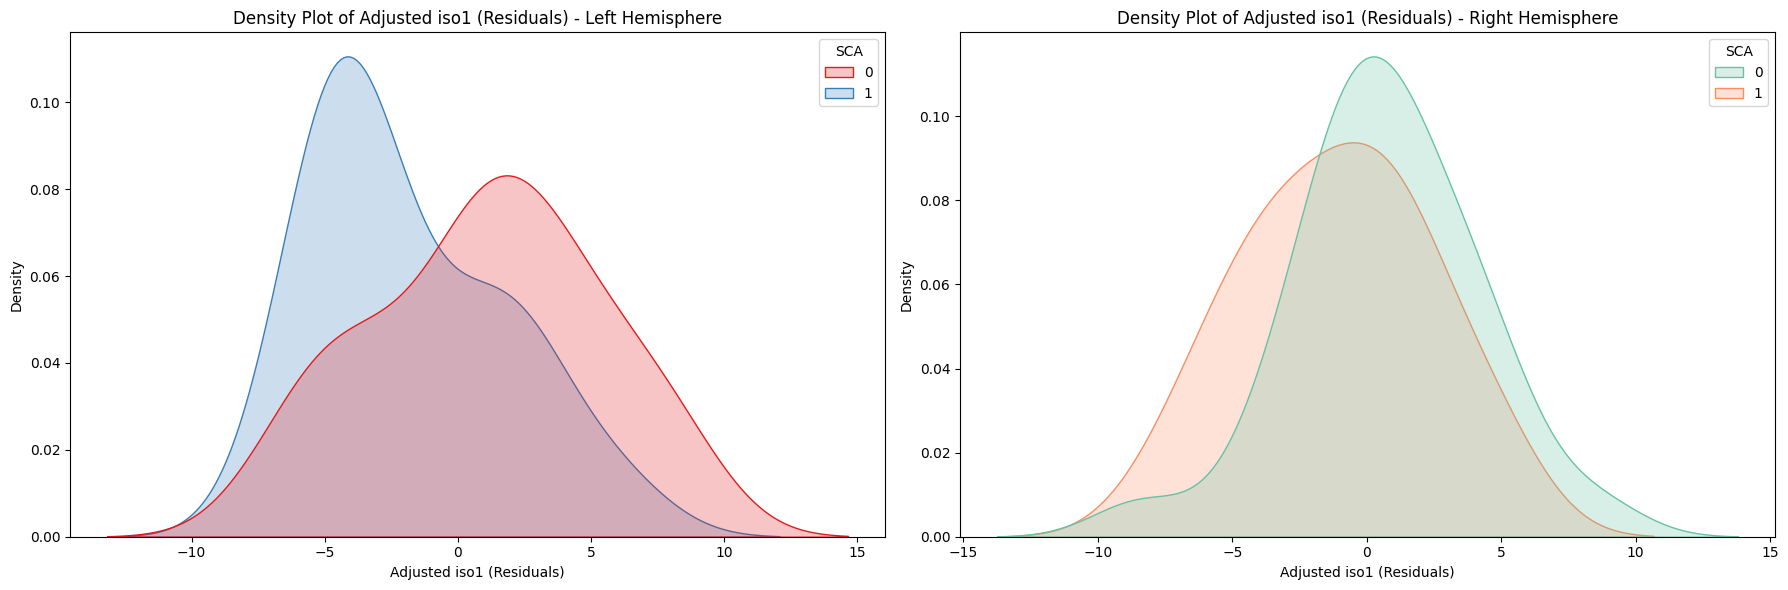

In [183]:
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Plot for left hemisphere (assuming side_numeric == 0 means left)
sns.kdeplot(data=df_cleaned[df_cleaned['side_numeric'] == 0], x=new_name, hue='SCA', 
            fill=True, common_norm=False, palette="Set1", ax=axs[0])
axs[0].set_title("Density Plot of Adjusted iso1 (Residuals) - Left Hemisphere")
axs[0].set_xlabel("Adjusted iso1 (Residuals)")
axs[0].set_ylabel("Density")

# Plot for right hemisphere (assuming side_numeric == 1 means right)
sns.kdeplot(data=df_cleaned[df_cleaned['side_numeric'] == 1], x=new_name, hue='SCA', 
            fill=True, common_norm=False, palette="Set2", ax=axs[1])
axs[1].set_title("Density Plot of Adjusted iso1 (Residuals) - Right Hemisphere")
axs[1].set_xlabel("Adjusted iso1 (Residuals)")
axs[1].set_ylabel("Density")

plt.tight_layout()
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\GLM_ctl_Sca1\difference_density_residual_byHem.png')
plt.show()


C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\graphics\factorplots.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isinstance(x[0], str):
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\graphics\factorplots.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = data.groupby(['trace', 'x']).aggregate(func).reset_index()


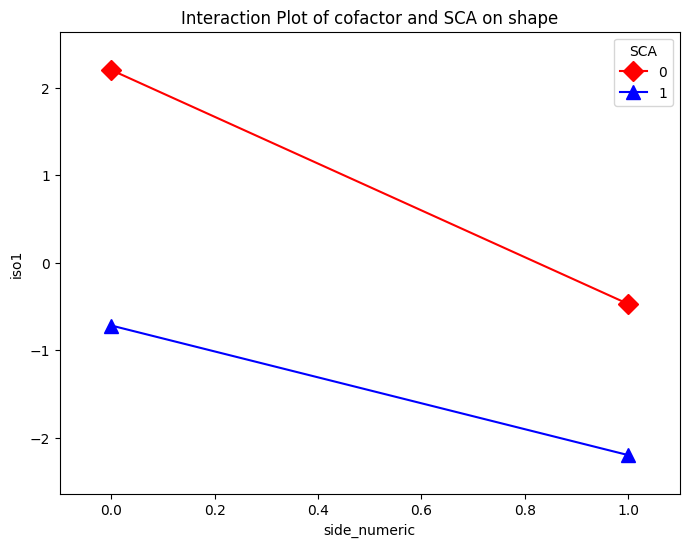

In [133]:
###########  Interaction plot for cofactors  ###########
from statsmodels.graphics.factorplots import interaction_plot

df = combined
curData = 'iso1'
cofactor = 'side_numeric' #'Sex', 'Age', 'side_numeric'

# Interaction plot for cofactor
fig, ax = plt.subplots(figsize=(8, 6))
interaction_plot(df[cofactor], df['SCA'], df[curData], ax=ax, colors=['red', 'blue'], markers=['D', '^'], ms=10)
plt.title("Interaction Plot of cofactor and SCA on shape")
plt.xlabel(cofactor)
plt.ylabel(curData)
plt.show()

Text(0, 0.5, 'iso1')

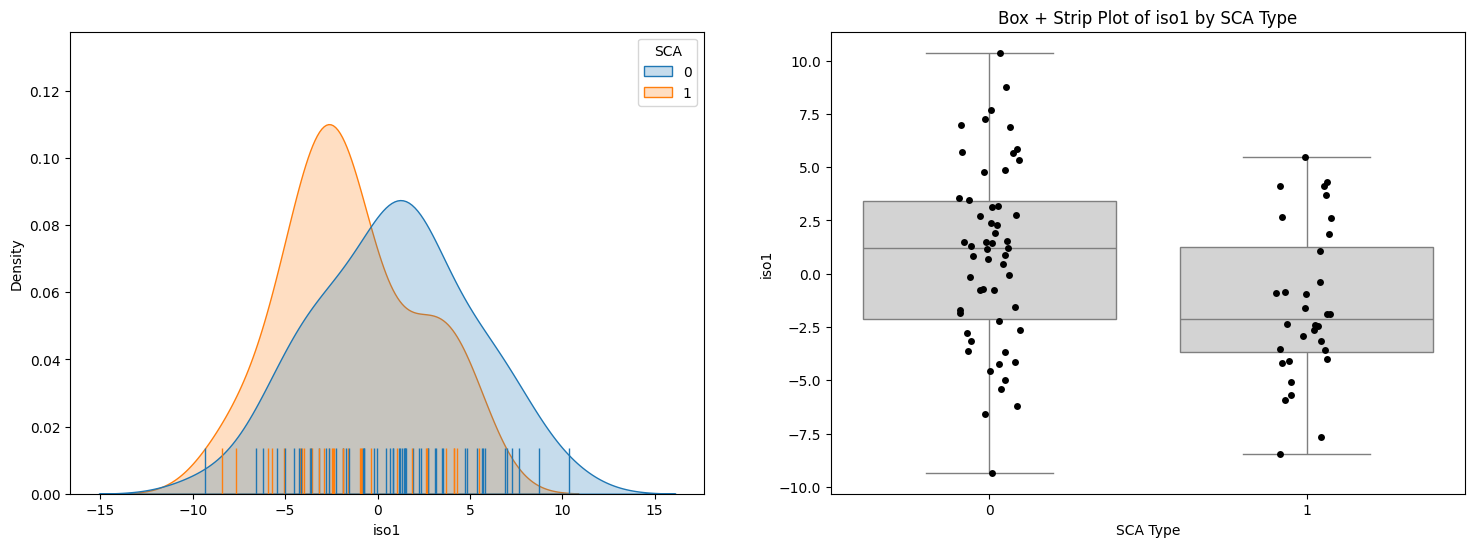

In [135]:
###############  density plot and Box+strip plot  ################

df = combined
curData = 'iso1'

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(data=df, x=curData, hue='SCA', fill=True, common_norm=False, ax=axs[0])
sns.rugplot(data=df, x=curData, hue='SCA', height=0.1, legend=False, ax=axs[0])
plt.title('Density Plot with Rug of ' + curData + ' by SCA Type')
plt.xlabel(curData)
plt.ylabel('Density')

sns.boxplot(x='SCA', y=curData, data=df, color='lightgray', ax=axs[1])
sns.stripplot(x='SCA', y=curData, data=df, color='black', jitter=True)
plt.title('Box + Strip Plot of ' + curData + ' by SCA Type')
plt.xlabel('SCA Type')
plt.ylabel(curData)


Text(0, 0.5, 'Density')

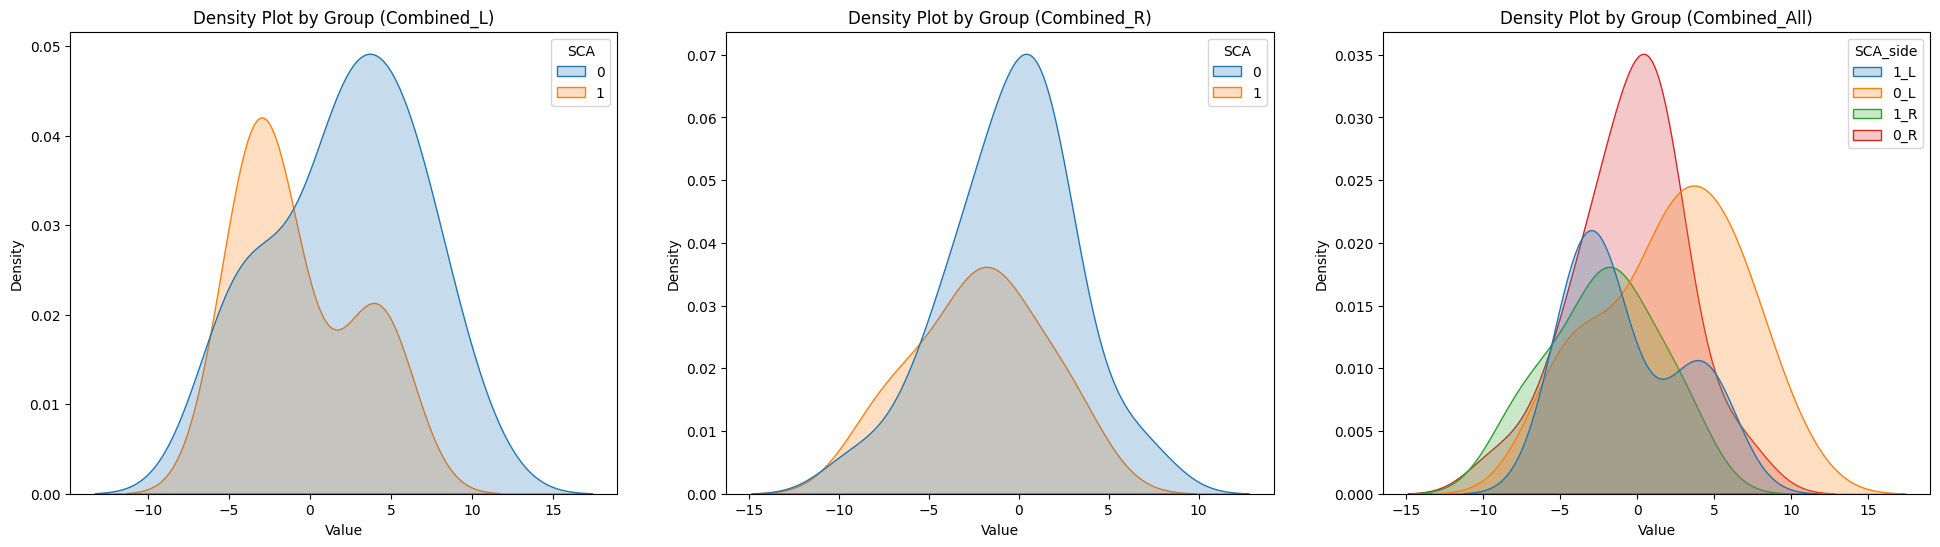

In [137]:
#################  density plot multiple groups, compare hemispheres  ##################

fig, axs = plt.subplots(1, 3, figsize=(24, 6))  # 3 subplots in a row, larger figure size for better spacing
# First plot
sns.kdeplot(data=combined_L, x='iso1', hue='SCA', fill=True, ax=axs[0])
axs[0].set_title('Density Plot by Group (Combined_L)')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Density')

# Second plot
sns.kdeplot(data=combined_R, x='iso1', hue='SCA', fill=True, ax=axs[1])
axs[1].set_title('Density Plot by Group (Combined_R)')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Density')

# third plot
sns.kdeplot(data=combined, x='iso1', hue='SCA_side', fill=True, ax=axs[2]) # default colors
axs[2].set_title('Density Plot by Group (Combined_All)')
axs[2].set_xlabel('Value')
axs[2].set_ylabel('Density')

Text(0, 0.5, 'Density')

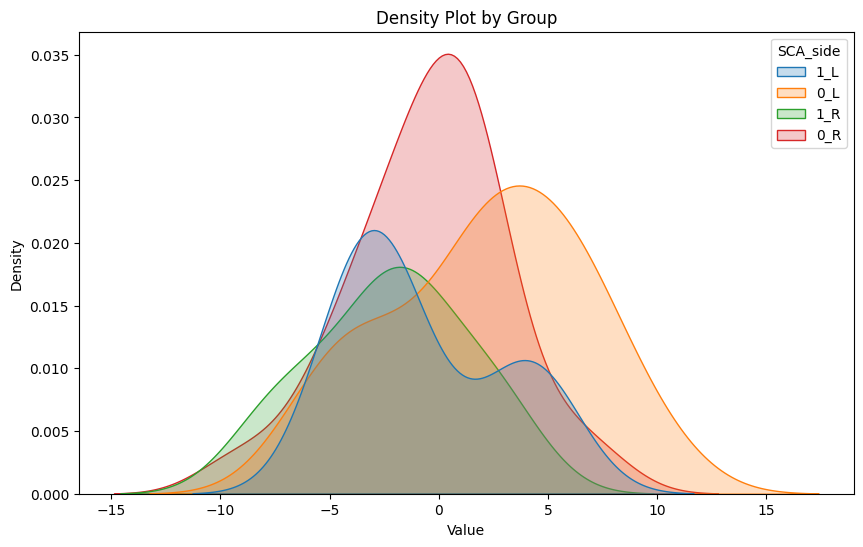

In [139]:
#################  density plot multiple groups  ##################

plt.figure(figsize=(10, 6))
sns.kdeplot(data=combined, x='iso1', hue='SCA_side', fill=True) # default colors

# Customize the plot
plt.title('Density Plot by Group')
plt.xlabel('Value')
plt.ylabel('Density')

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_dec_2024\density_combined_ctl_SCA1_time2_inBoth_max_byHemisphere.png')

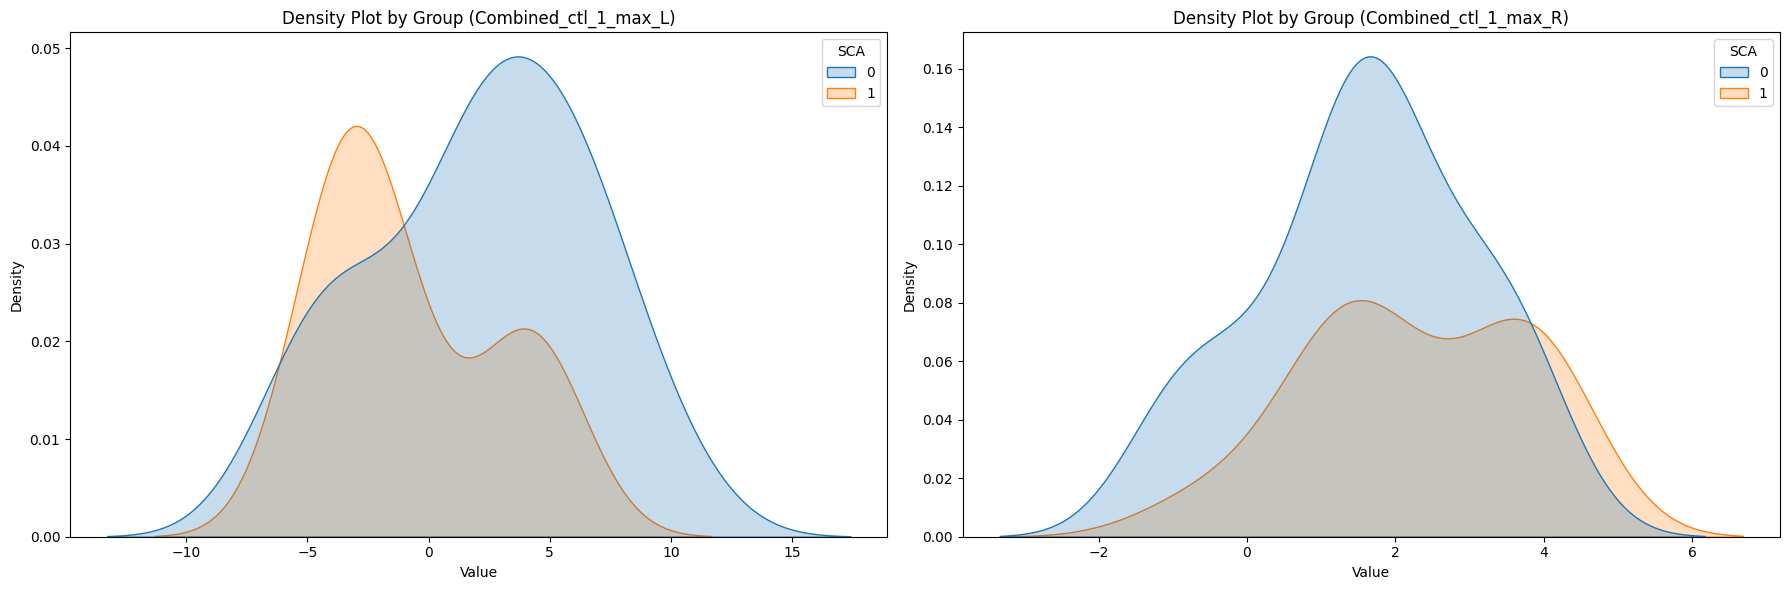

In [17]:
################################  plotting left and right hemisphere  #################################
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# First plot
sns.kdeplot(data=combined_L, x='iso1', hue='SCA', fill=True, ax=axs[0])
axs[0].set_title('Density Plot by Group (Combined_ctl_1_max_L)')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Density')

# Second plot
sns.kdeplot(data=combined_R, x='UMAP2_U3', hue='SCA', fill=True, ax=axs[1])
axs[1].set_title('Density Plot by Group (Combined_ctl_1_max_R)')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Density')

# Adjust layout for better spacing
plt.tight_layout()
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots\density_ctl_1_iso1_max_L_R.png')

# Show the plots
plt.show()

############################## FOR RECORD ONLY ###############################

########  Perform ANCOVA and GLM analysis, Gaussian distribution  ########
########  Perform ranked ANCOVA, non-Gaussian distribution  ########
########   Adding covariates, two or multiple groups   ########

def ancovaGLMTests(df,measures,x_var):   # df, measures are the dependant variables, x_var is the independant variables
    df.loc[:, 'SCA'] = df['SCA'].astype('category')       # Ensure 'SCA' is a categorical variable    
    results_dict = {}                                     # Initialize a dictionary to store results
   
    covariates = 'Age + C(side)'                        # if NOT from the same centre  
    ##covariates = 'Age + C(side) + C(CodeICM)'    
    ##covariates = 'Age + C(Sex) + C(side) + C(CodeICM)'  

    #covariates = 'Age + C(Sex) + C(side) + Age_onset'    # if ONLY patients
    #covariatesRanked = ['Age','Sex','side','Age_onset']         
    #covariates = 'Age + C(side) + Age_onset'              
    #covariatesRanked = ['Age','side','Age_onset']         
    #covariates = 'Age + C(side)'              
    covariatesRanked = ['Age','side']            
    
    for measure in measures:
        formula = rf'{measure} ~ {x_var} + {covariates}'   # Define the model formula dynamically       
        model = smf.ols(formula, data=df).fit()            # Fit the model        
        print(rf'ANCOVA results for ###################    {measure}    ###################:')
        print(model.summary())
        print("\n" + "="*80 + "\n")  # Divider between each measure's output
        anova_table = sm.stats.anova_lm(model, typ=2) 
        print(anova_table)
        
        ###################      Format p-value in scientific notation     ###################
        summary_table = pd.DataFrame({         
            'Coefficient': model.params,
            'Standard Error': model.bse,
            't-Value': model.tvalues,
            'P-Value': model.pvalues.apply(lambda x: f"{x:.2e}")  # Format p-values in scientific notation
        })        
        #print("Custom ANCOVA Results:")     # Display formatted results, ONLY if scientific notation needed
        #print(summary_table)

        ########################################     GLM     #######################################
        print("============================   GLM " + measure + "  ============================")
        glm_model = smf.glm(formula=formula, data=df).fit()
        print(f"GLM results for {measure}:\n")
        print(glm_model.summary())

        #######################    Ranked ANCOVA for non_Gaussian data    ########################
        covariatesRanked = [cov.strip() for cov in covariatesRanked if cov.strip()]

        df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable       
        # Formula: Outcome ~ Group + Covariate  
        formula = rf"Ranked_Outcome ~ {x_var} + {' + '.join(covariatesRanked)}"    # Step 2: Perform ANCOVA on Ranked Data
        model = smf.ols(formula, data=df).fit()

        # Display the summary
        print("========================   Rank-Based ANCOVA: " + measure + "==========================" )
        print(model.summary())

measures_complete = [
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4',
    'surface_talairach','surface_native','maxdepth_talairach','maxdepth_native','meandepth_talairach',
    'meandepth_native','hull_junction_length_talairach','hull_junction_length_native','GM_thickness','opening',
    'iso1_asy','iso2_asy','iso3_asy','UMAP1_U1_asy','UMAP1_U2_asy','UMAP1_U3_asy','UMAP2_U3_asy','UMAP1_U4_asy','UMAP2_U4_asy',
    'surface_talairach_asy','surface_native_asy','maxdepth_talairach_asy','maxdepth_native_asy','meandepth_talairach_asy',
    'meandepth_native_asy','hull_junction_length_talairach_asy','hull_junction_length_native_asy','GM_thickness_asy','opening_asy'
]
curMeasures = [                                  # the dependant variables, 
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4','iso1_asy','iso2_asy','iso3_asy'
]

cur_x_vars = ['SCA']                         # the independant variables
#cur_x_vars = ['SARA','CAG','CCFS','INAS'] 
#cur_x_vars = ['Age_onset']  
#cur_x_vars = ['CAG'] 


# Run the function
for x_var in cur_x_vars:
    print(rf'###################################        {x_var}        #####################################')     
    if x_var == 'SCA':
        ancovaGLMTests(combined, curMeasures, x_var)        
    if x_var == 'SARA':
        ancovaGLMTests(combined_only_SCA, curMeasures, x_var)
    if x_var == 'CAG':
        ancovaGLMTests(combined_CAG_only_SCA, curMeasures, x_var) 
    if x_var == 'CCFS':
        if len(combined_CCFS_only_SCA) > 0:
            ancovaGLMTests(combined_CCFS_only_SCA, curMeasures, x_var) 
        else:
            print('No CCFS info.')
    if x_var == 'INAS':
        if len(combined_INAS_only_SCA) > 0:
            ancovaGLMTests(combined_INAS_only_SCA, curMeasures, x_var) 
        else:
            print('No INAS info.')
    if x_var == 'Age_onset':
        ancovaGLMTests(combined_CAG_only_SCA, curMeasures, x_var)       

#############  Enable scrolling for the output  #############
from IPython.core.display import display, HTML
display(HTML("<style>.output_scroll {height: 300px; overflow-y: scroll;}</style>")) #right click on output to enable scrolling